<a href="https://colab.research.google.com/github/Parasshirishvaidya/learning-time-series/blob/main/Module1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates #specialized of handling date/time data plots

In [2]:
from statsmodels.datasets import get_rdataset

In [3]:
df = get_rdataset("AirPassengers").data

df.columns=["months","passengers"]

df.head() #The Month Column will be in decimal format which we can convert

,months,passengers
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


In [4]:
#Converting Months from decimal to YYYY/MM/DD format

df.index=pd.date_range(start="1949-01",periods=144,freq="MS")
df=df.drop(columns=["months"])
df.head()

,passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
df.shape

(144, 1)

In [6]:
df.describe()

,passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [7]:
df.isnull().sum()

,0
passengers,0


##Visualizations

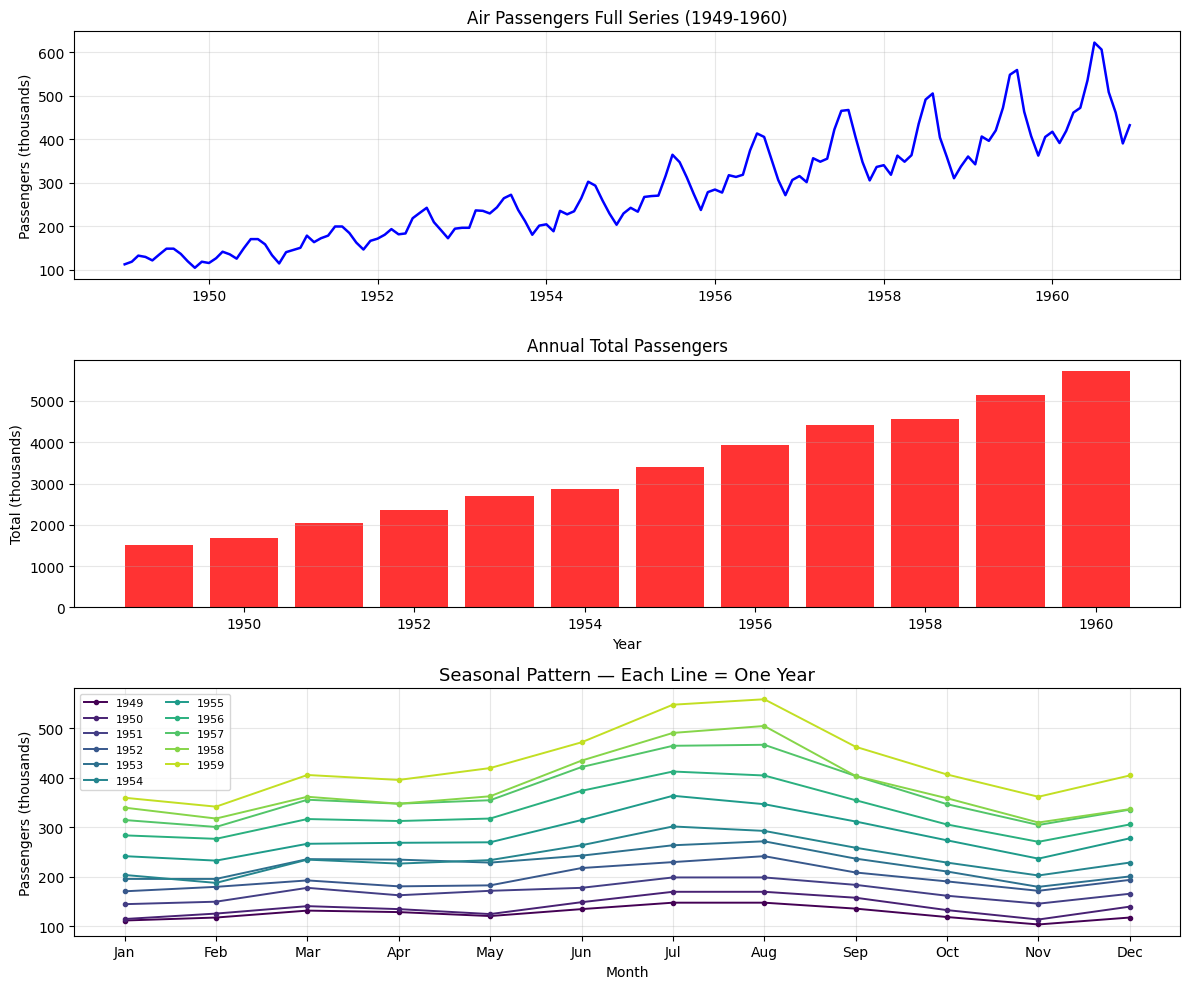

In [8]:
fig,axes=plt.subplots(3,1,figsize=(12,10))

axes[0].plot(df.index,df["passengers"],color="blue",linewidth=1.8)
axes[0].set_title("Air Passengers Full Series (1949-1960)")
axes[0].set_ylabel("Passengers (thousands)")
axes[0].grid(True, alpha=0.3)

annual=df.resample("YE").sum()
axes[1].bar(annual.index.year,annual["passengers"],color="red",alpha=0.8)
axes[1].set_title("Annual Total Passengers")
axes[1].set_ylabel("Total (thousands)")
axes[1].set_xlabel("Year")
axes[1].grid(True, alpha=0.3, axis="y")

#Plotting Seasonal Pattern-each year as a separate line
colors=plt.cm.viridis(np.linspace(0,1,12)) #Creates a list of 12 colors gradually changing shade
for i,year in enumerate(range(1949,1960)):
  yearly=df[df.index.year==year]["passengers"].values
  axes[2].plot(range(1,13),yearly,marker="o",markersize=3,
              label=str(year),color=colors[i],linewidth=1.4)
axes[2].set_title("Seasonal Pattern — Each Line = One Year", fontsize=13)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Passengers (thousands)")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])
axes[2].legend(loc="upper left", fontsize=8, ncol=2)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
print(colors.shape) #RGBA COLOR RED GREEN BLUE ALPHA

(12, 4)


In [10]:
yearly

array([360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405])

##Key Time Series Operations

In [11]:
monthly=df.copy()
quaterly=df.resample("QE").mean()
annual=df.resample("YE").sum()

In [12]:
#Shifting
df["passengers_lag1"]=df["passengers"].shift(1)
df["passengers_lag12"]=df["passengers"].shift(12)

In [13]:
df.tail(12)

,passengers,passengers_lag1,passengers_lag12
1960-01-01,417,405.0,360.0
1960-02-01,391,417.0,342.0
1960-03-01,419,391.0,406.0
1960-04-01,461,419.0,396.0
1960-05-01,472,461.0,420.0
1960-06-01,535,472.0,472.0
1960-07-01,622,535.0,548.0
1960-08-01,606,622.0,559.0
1960-09-01,508,606.0,463.0
1960-10-01,461,508.0,407.0


In [14]:
#Percentage change
df["mom_change"] = df["passengers"].pct_change(1) * 100    # month over month
df["yoy_change"] = df["passengers"].pct_change(12) * 100   # year over year

In [15]:
df[["passengers","mom_change","yoy_change"]].tail(6).round(1)

,passengers,mom_change,yoy_change
1960-07-01,622,16.3,13.5
1960-08-01,606,-2.6,8.4
1960-09-01,508,-16.2,9.7
1960-10-01,461,-9.3,13.3
1960-11-01,390,-15.4,7.7
1960-12-01,432,10.8,6.7


In [16]:
#Rolling Window
df["rolling_mean_12"]=df["passengers"].rolling(window=12).mean() #12-Month Moving Average
df["rolling_std_12"]=df["passengers"].rolling(window=12).std()

In [17]:
df[["passengers","rolling_mean_12","rolling_std_12"]].tail(5)

,passengers,rolling_mean_12,rolling_std_12
1960-08-01,606,463.333333,83.630500
1960-09-01,508,467.083333,84.617276
1960-10-01,461,471.583333,82.541954
1960-11-01,390,473.916667,79.502382
1960-12-01,432,476.166667,77.737125


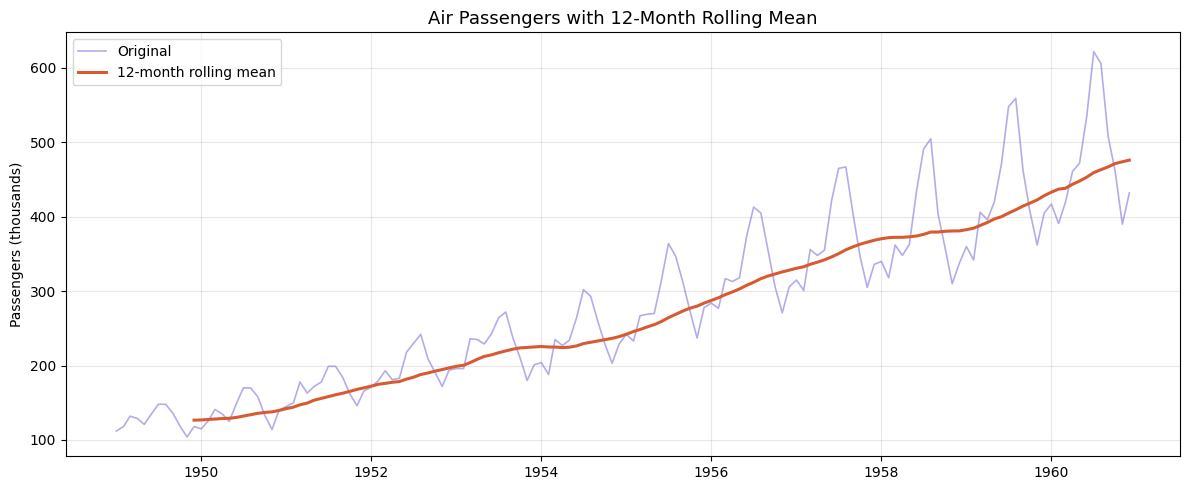

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["passengers"],
         label="Original", color="#7F77DD", alpha=0.6, linewidth=1.2)
plt.plot(df.index, df["rolling_mean_12"],
         label="12-month rolling mean", color="#D85A30", linewidth=2.2)
plt.title("Air Passengers with 12-Month Rolling Mean", fontsize=13)
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The rolling mean smooths out the seasonality and shows you the pure trend

#Detrending

In [20]:
#Differencing
df["diff_1"]=df["passengers"].diff(1)
df["diff_2"]=df["diff_1"].diff(2)

In [22]:
print(df[["passengers", "diff_1", "diff_2"]].head(10))

            passengers  diff_1  diff_2
1949-01-01         112     NaN     NaN
1949-02-01         118     6.0     NaN
1949-03-01         132    14.0     NaN
1949-04-01         129    -3.0    -9.0
1949-05-01         121    -8.0   -22.0
1949-06-01         135    14.0    17.0
1949-07-01         148    13.0    21.0
1949-08-01         148     0.0   -14.0
1949-09-01         136   -12.0   -25.0
1949-10-01         119   -17.0   -17.0


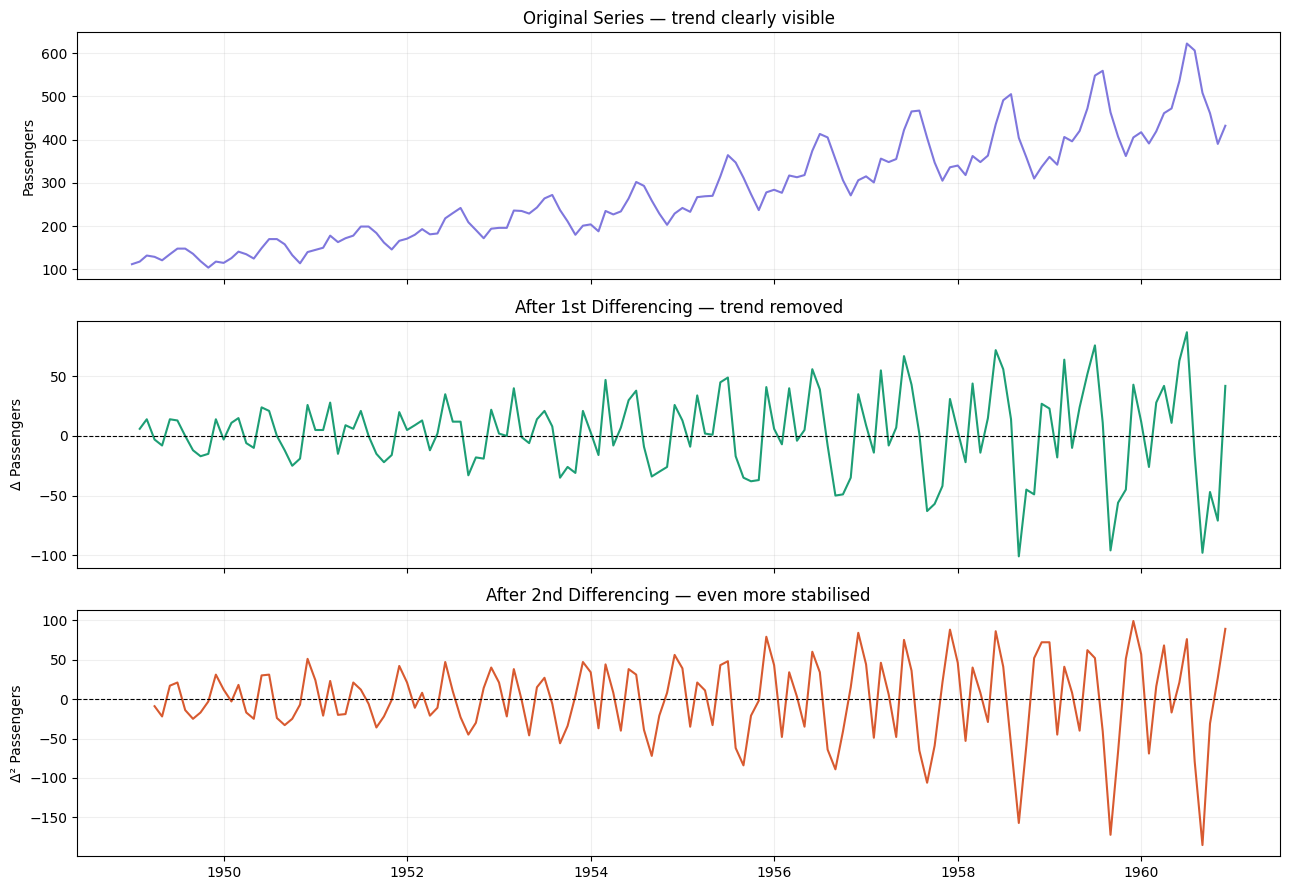

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(df.index, df["passengers"], color="#7F77DD", linewidth=1.5)
axes[0].set_title("Original Series — trend clearly visible", fontsize=12)
axes[0].set_ylabel("Passengers")
axes[0].grid(True, alpha=0.2)

axes[1].plot(df.index, df["diff_1"], color="#1D9E75", linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("After 1st Differencing — trend removed", fontsize=12)
axes[1].set_ylabel("Δ Passengers")
axes[1].grid(True, alpha=0.2)

axes[2].plot(df.index, df["diff_2"], color="#D85A30", linewidth=1.5)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("After 2nd Differencing — even more stabilised", fontsize=12)
axes[2].set_ylabel("Δ² Passengers")
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [26]:
from scipy import stats

In [25]:
X=np.arange(len(df))
y=df["passengers"].values

In [27]:
slope,intercept,r_value,_,_=stats.linregress(X,y)

In [28]:
df["trend_line"]=intercept+slope*X
df["detrended_regression"]=df["passengers"]-df["trend_line"]

In [29]:
df[["passengers","detrended_regression"]].head()

,passengers,detrended_regression
1949-01-01,112,21.690038
1949-02-01,118,25.032854
1949-03-01,132,36.375670
1949-04-01,129,30.718487
1949-05-01,121,20.061303


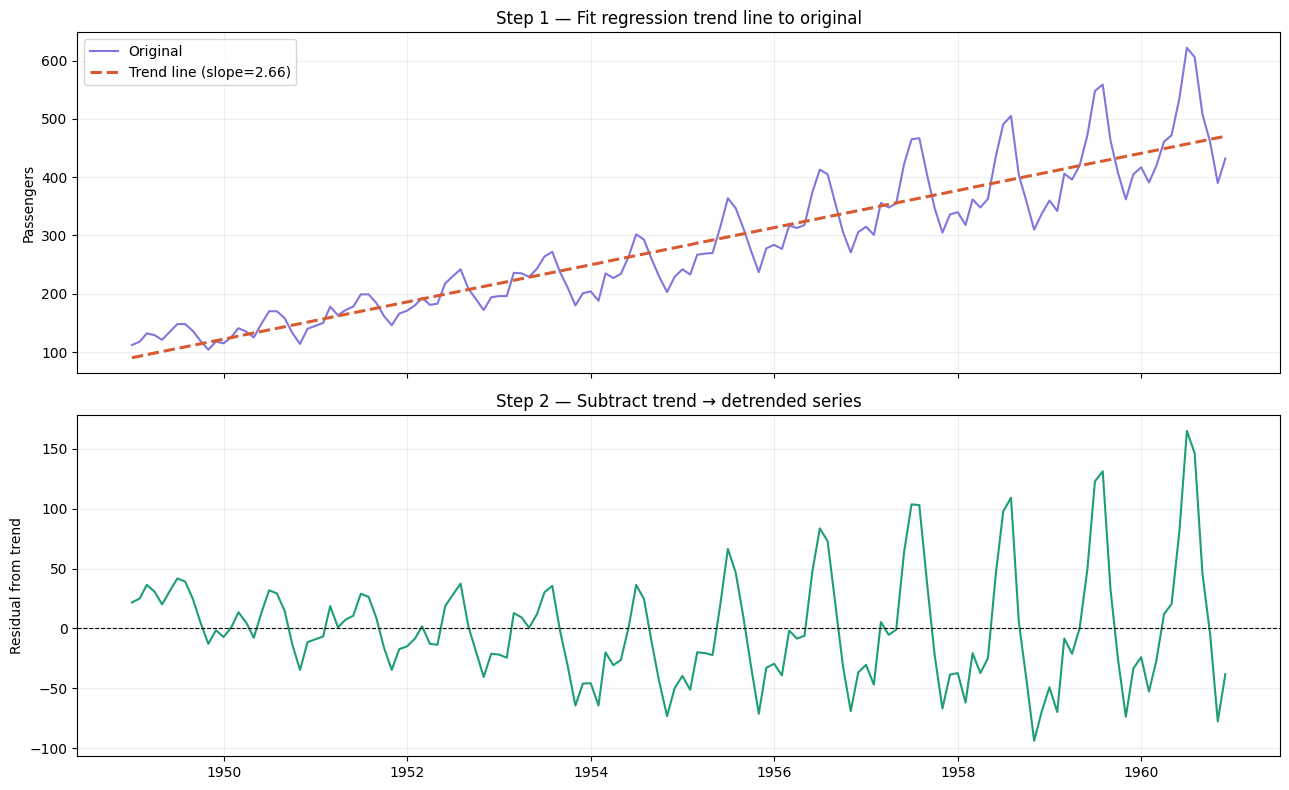

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df["passengers"],
             color="#7F77DD", linewidth=1.5, label="Original")
axes[0].plot(df.index, df["trend_line"],
             color="#D85A30", linewidth=2.2,
             linestyle="--", label=f"Trend line (slope={slope:.2f})")
axes[0].set_title("Step 1 — Fit regression trend line to original", fontsize=12)
axes[0].set_ylabel("Passengers")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

axes[1].plot(df.index, df["detrended_regression"],
             color="#1D9E75", linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Step 2 — Subtract trend → detrended series", fontsize=12)
axes[1].set_ylabel("Residual from trend")
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [33]:
df["cma_trend"] = df["passengers"].rolling(window=12, center=True).mean()

df["detrended_ma"] = df["passengers"] - df["cma_trend"]

print(df[["passengers", "cma_trend", "detrended_ma"]].iloc[5:15])

            passengers   cma_trend  detrended_ma
1949-06-01         135         NaN           NaN
1949-07-01         148  126.666667     21.333333
1949-08-01         148  126.916667     21.083333
1949-09-01         136  127.583333      8.416667
1949-10-01         119  128.333333     -9.333333
1949-11-01         104  128.833333    -24.833333
1949-12-01         118  129.166667    -11.166667
1950-01-01         115  130.333333    -15.333333
1950-02-01         126  132.166667     -6.166667
1950-03-01         141  134.000000      7.000000


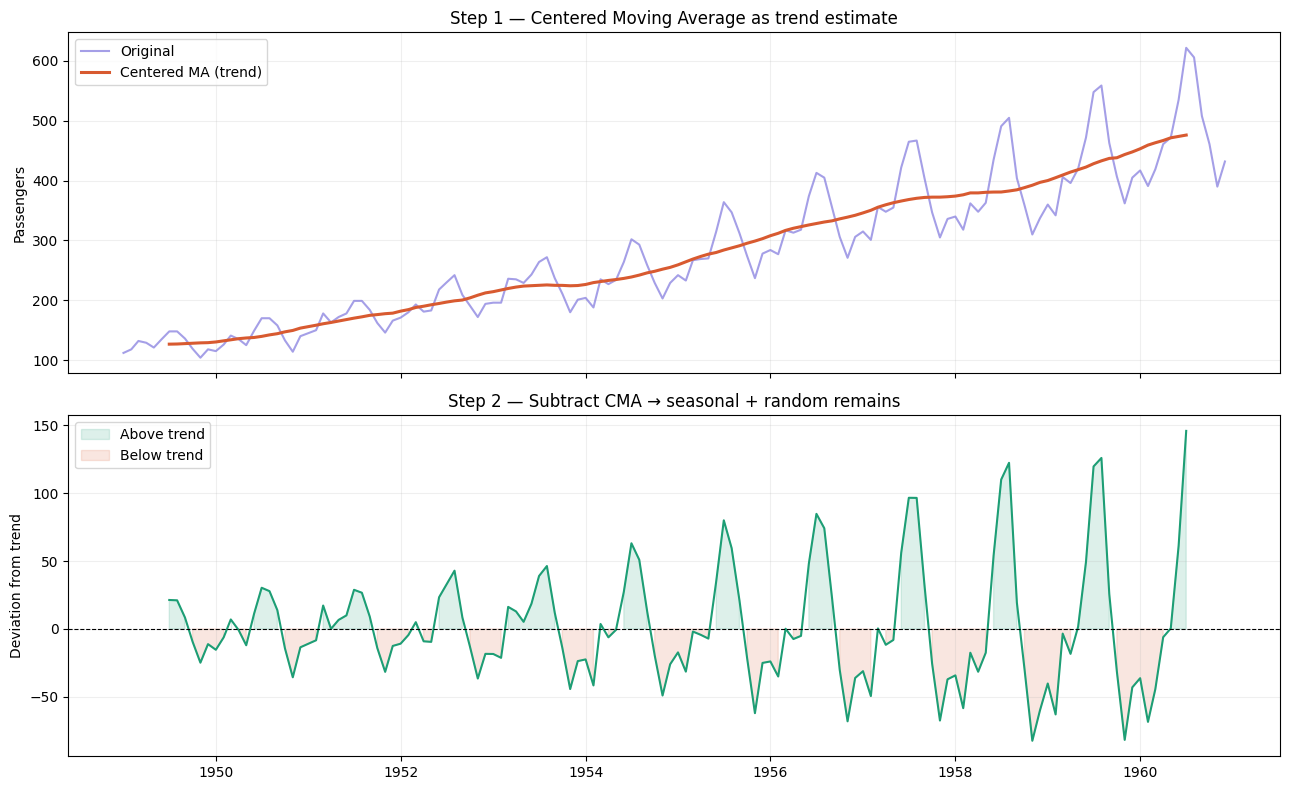

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df["passengers"],
             color="#7F77DD", linewidth=1.5, alpha=0.7, label="Original")
axes[0].plot(df.index, df["cma_trend"],
             color="#D85A30", linewidth=2.2, label="Centered MA (trend)")
axes[0].set_title("Step 1 — Centered Moving Average as trend estimate", fontsize=12)
axes[0].set_ylabel("Passengers")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

axes[1].plot(df.index, df["detrended_ma"],
             color="#1D9E75", linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].fill_between(df.index, df["detrended_ma"], 0,
                      where=df["detrended_ma"] > 0,
                      color="#1D9E75", alpha=0.15, label="Above trend")
axes[1].fill_between(df.index, df["detrended_ma"], 0,
                      where=df["detrended_ma"] < 0,
                      color="#D85A30", alpha=0.15, label="Below trend")
axes[1].set_title("Step 2 — Subtract CMA → seasonal + random remains", fontsize=12)
axes[1].set_ylabel("Deviation from trend")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()